# # UK E-Commerce Customer & Revenue Analysis

**Author:** Arunav Bhattacharjee  
**Dataset:** UCI Online Retail Dataset (2010–2011)  
**Tools:** Python, Pandas, NumPy, Matplotlib

## Business Objective
A UK-based online retailer wants to understand which customers drive the most 
revenue and what actions to take to protect and grow that revenue.

This analysis uses RFM segmentation (Recency, Frequency, Monetary) across 
500,000+ transactions to identify high-value customer segments and deliver 
three prioritised business recommendations.

---

## Step 1 — Load the Data
Loading the raw dataset containing 500,000+ retail transactions from a UK-based 
online retailer between 2010 and 2011.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel('Online Retail.xlsx')

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Step 2 — Clean the Data
Removing rows with missing Customer IDs, negative quantities (returns), 
and zero prices. Creating a Revenue column (Quantity × UnitPrice) to 
enable monetary analysis.

In [2]:
# Remove rows with missing Customer ID
df = df.dropna(subset=['CustomerID'])

# Remove returns (negative quantities)
df = df[df['Quantity'] > 0]

# Remove rows with zero or negative price
df = df[df['UnitPrice'] > 0]

# Create a Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print("Clean dataset shape:", df.shape)

Clean dataset shape: (397884, 9)


## Step 3 — RFM Segmentation
Calculating Recency, Frequency, and Monetary value per customer.

- **Recency** — days since last purchase
- **Frequency** — number of unique orders
- **Monetary** — total revenue generated

Each customer is scored 1–4 on each dimension to identify behavioural segments.

In [3]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Set reference date
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM per customer
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(rfm.shape)
rfm.head()

(4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


## Step 4 — Revenue Concentration Analysis
Identifying what proportion of total revenue is generated by the top 5% 
of customers — a key risk indicator for the business.

In [4]:
# Sort customers by revenue
rfm_sorted = rfm.sort_values('Monetary', ascending=False)

# Top 5% of customers
top_5_pct = int(len(rfm_sorted) * 0.05)
top_customers = rfm_sorted.head(top_5_pct)

# What % of total revenue do they represent?
pct_revenue = top_customers['Monetary'].sum() / rfm_sorted['Monetary'].sum() * 100
print(f"Number of top 5% customers: {top_5_pct}")
print(f"Top 5% of customers generate {pct_revenue:.1f}% of total revenue")

Number of top 5% customers: 216
Top 5% of customers generate 50.3% of total revenue


## Step 5 — Monthly Revenue Trend
Visualising revenue over time to identify seasonality patterns and 
overall business trajectory.

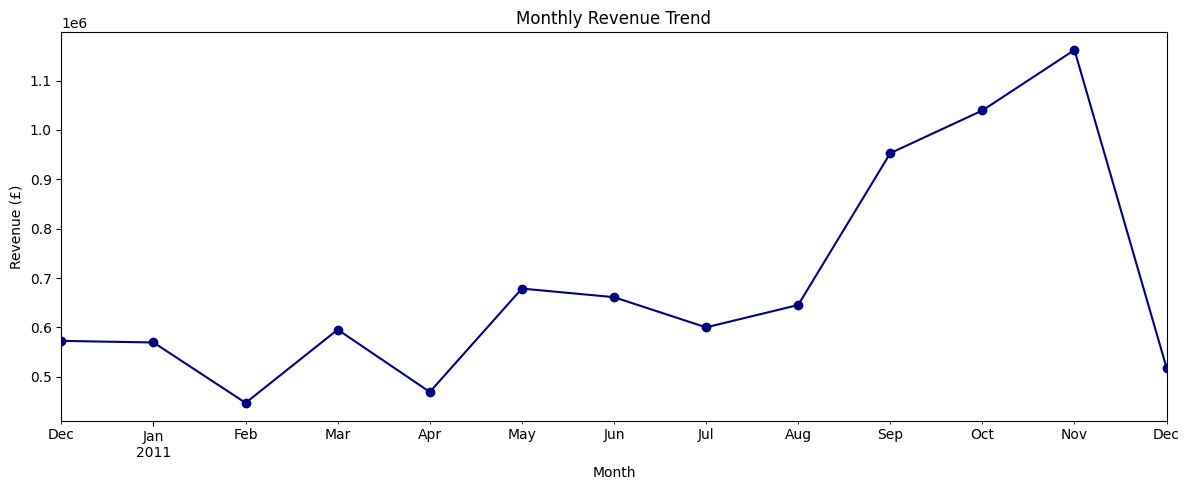

In [5]:
# Monthly revenue trend
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(12,5))
monthly.plot(kind='line', marker='o', color='navy')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('monthly_revenue.png')
plt.show()

## Step 6 — Customer Segmentation & Revenue by Segment
Grouping customers into five behavioural segments based on RFM scores 
and visualising total revenue contribution per segment.

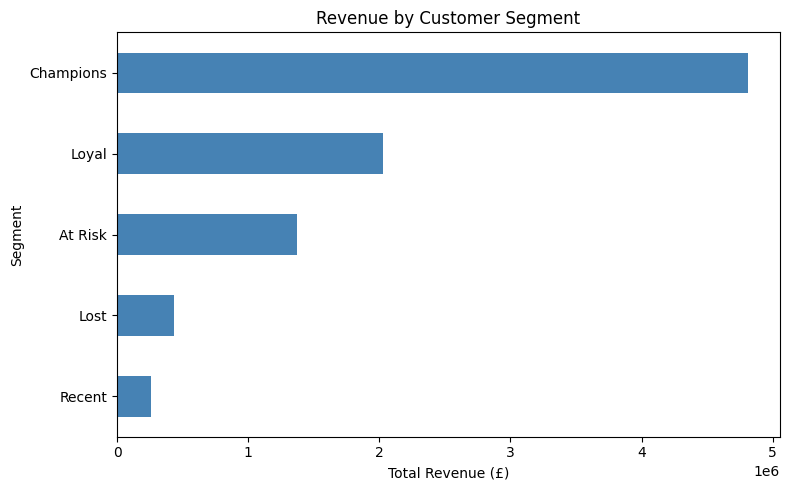

In [6]:
# Score each customer 1-4 on RFM dimensions
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Create segments
def segment(row):
    if row['R_Score'] == '4' and row['M_Score'] == '4':
        return 'Champions'
    elif row['R_Score'] >= '3' and row['M_Score'] >= '3':
        return 'Loyal'
    elif row['R_Score'] >= '3':
        return 'Recent'
    elif row['M_Score'] >= '3':
        return 'At Risk'
    else:
        return 'Lost'

rfm['R_Score'] = rfm['R_Score'].astype(str)
rfm['F_Score'] = rfm['F_Score'].astype(str)
rfm['M_Score'] = rfm['M_Score'].astype(str)
rfm['Segment'] = rfm.apply(segment, axis=1)

# Plot revenue by segment
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values()

plt.figure(figsize=(8,5))
seg_revenue.plot(kind='barh', color='steelblue')
plt.title('Revenue by Customer Segment')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('revenue_by_segment.png')
plt.show()

## Business Recommendations

**Analysis:** RFM segmentation of 397,884 transactions across 4,338 customers 
revealed that the top 5% of customers (216 individuals) generate 50.3% of 
total revenue — a significant concentration risk requiring immediate action.

**Recommendation 1 — Protect Champions with a Loyalty Programme**
The top 5% drive over half of all revenue. A tiered rewards scheme with 
early access, personalised offers, and dedicated account management would 
reduce churn risk in this critical segment.

**Recommendation 2 — Win Back At-Risk High-Value Customers**
High-spending customers who haven't purchased in 90+ days should receive 
a targeted re-engagement campaign with a time-limited discount — 
recovering even 20% of this group would materially impact revenue.

**Recommendation 3 — Upsell Loyal Customers to Champion Tier**
The Loyal segment represents the highest growth opportunity. Personalised 
product recommendations based on past purchase patterns could move a 
portion of this group into the top spending tier.